# Diabetes dataset using pyspark MLLib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
! pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.1-py2.py3-none-any.whl size=317488491 sha256=1a6f123db5bd3f089dae7eddbf76c7f031731a1a1aeffc5b803a7c9db676b2ca
  Stored in directory: /root/.cache/pip/wheels/80/1d/60/2c256ed38dddce2fdd93be545214a63e02fbd8d74fb0b7f3a6
Successfully built pyspark


In [ ]:
from pyspark.sql import SparkSession

# Initialize SparkSession
spark = SparkSession.builder \
    .appName("spark") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

# Load and Explore dataset

In [ ]:
df = spark.read.csv("/content/drive/MyDrive/content/heart.csv", header=True, inferSchema=True)#

In [ ]:
df.show()


+---+---+---+--------+----+---+-------+-------+-----+-------+-----+---+----+------+
|age|sex| cp|trestbps|chol|fbs|restecg|thalach|exang|oldpeak|slope| ca|thal|target|
+---+---+---+--------+----+---+-------+-------+-----+-------+-----+---+----+------+
| 52|  1|  0|     125| 212|  0|      1|    168|    0|    1.0|    2|  2|   3|     0|
| 53|  1|  0|     140| 203|  1|      0|    155|    1|    3.1|    0|  0|   3|     0|
| 70|  1|  0|     145| 174|  0|      1|    125|    1|    2.6|    0|  0|   3|     0|
| 61|  1|  0|     148| 203|  0|      1|    161|    0|    0.0|    2|  1|   3|     0|
| 62|  0|  0|     138| 294|  1|      1|    106|    0|    1.9|    1|  3|   2|     0|
| 58|  0|  0|     100| 248|  0|      0|    122|    0|    1.0|    1|  0|   2|     1|
| 58|  1|  0|     114| 318|  0|      2|    140|    0|    4.4|    0|  3|   1|     0|
| 55|  1|  0|     160| 289|  0|      0|    145|    1|    0.8|    1|  1|   3|     0|
| 46|  1|  0|     120| 249|  0|      0|    144|    0|    0.8|    2|  0|   3|

In [ ]:
print(type(df))


<class 'pyspark.sql.dataframe.DataFrame'>


In [ ]:
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- sex: integer (nullable = true)
 |-- cp: integer (nullable = true)
 |-- trestbps: integer (nullable = true)
 |-- chol: integer (nullable = true)
 |-- fbs: integer (nullable = true)
 |-- restecg: integer (nullable = true)
 |-- thalach: integer (nullable = true)
 |-- exang: integer (nullable = true)
 |-- oldpeak: double (nullable = true)
 |-- slope: integer (nullable = true)
 |-- ca: integer (nullable = true)
 |-- thal: integer (nullable = true)
 |-- target: integer (nullable = true)



In [ ]:
print((df.count(),len(df.columns)))
df.groupBy('target').count().show()

(1025, 14)
+------+-----+
|target|count|
+------+-----+
|     1|  526|
|     0|  499|
+------+-----+



In [ ]:
spark.conf.set("spark.sql.debug.maxToStringFields", 100)

df.describe().show()

+-------+-----------------+------------------+------------------+------------------+-----------------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+
|summary|              age|               sex|                cp|          trestbps|             chol|                fbs|           restecg|           thalach|              exang|           oldpeak|             slope|                ca|              thal|            target|
+-------+-----------------+------------------+------------------+------------------+-----------------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+
|  count|             1025|              1025|              1025|              1025|             1025|               1025|              1025|              1025|            

# Data cleaning & preparation



In [ ]:
for col in df.columns:
  print(col+":",df[df[col].isNull()].count())

age: 0
sex: 0
cp: 0
trestbps: 0
chol: 0
fbs: 0
restecg: 0
thalach: 0
exang: 0
oldpeak: 0
slope: 0
ca: 0
thal: 0
target: 0


In [ ]:
def count_zeros():
  columns_list =['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
  for i in columns_list:
    print(i+":",df[df[i]==0].count())

In [ ]:
from pyspark.sql.functions import *
for i in df.columns[1:6]:
  data = df.agg({i:'mean'}).first()[0]
  print("mean value for {} is {}".format(i,int(data)))
  df = df.withColumn(i,when(df[i]==0,int(data)).otherwise(df[i]))

mean value for sex is 0
mean value for cp is 0
mean value for trestbps is 131
mean value for chol is 246
mean value for fbs is 0


In [ ]:
df.show()

+---+---+---+--------+----+---+-------+-------+-----+-------+-----+---+----+------+
|age|sex| cp|trestbps|chol|fbs|restecg|thalach|exang|oldpeak|slope| ca|thal|target|
+---+---+---+--------+----+---+-------+-------+-----+-------+-----+---+----+------+
| 52|  1|  0|     125| 212|  0|      1|    168|    0|    1.0|    2|  2|   3|     0|
| 53|  1|  0|     140| 203|  1|      0|    155|    1|    3.1|    0|  0|   3|     0|
| 70|  1|  0|     145| 174|  0|      1|    125|    1|    2.6|    0|  0|   3|     0|
| 61|  1|  0|     148| 203|  0|      1|    161|    0|    0.0|    2|  1|   3|     0|
| 62|  0|  0|     138| 294|  1|      1|    106|    0|    1.9|    1|  3|   2|     0|
| 58|  0|  0|     100| 248|  0|      0|    122|    0|    1.0|    1|  0|   2|     1|
| 58|  1|  0|     114| 318|  0|      2|    140|    0|    4.4|    0|  3|   1|     0|
| 55|  1|  0|     160| 289|  0|      0|    145|    1|    0.8|    1|  1|   3|     0|
| 46|  1|  0|     120| 249|  0|      0|    144|    0|    0.8|    2|  0|   3|

# Correlation Analysis & Feature Selection

In [ ]:
for i in df.columns:
  print("Correlation to outcome for {} is {}".format(i,df.stat.corr('target',i)))

Correlation to outcome for age is -0.22932355126761092
Correlation to outcome for sex is -0.2795007572922623
Correlation to outcome for cp is 0.4348542500527372
Correlation to outcome for trestbps is -0.13877173373730076
Correlation to outcome for chol is -0.09996559423254127
Correlation to outcome for fbs is -0.041163547464651215
Correlation to outcome for restecg is 0.1344682087390891
Correlation to outcome for thalach is 0.4228954964828723
Correlation to outcome for exang is -0.43802855005584596
Correlation to outcome for oldpeak is -0.4384412701119451
Correlation to outcome for slope is 0.3455117514359987
Correlation to outcome for ca is -0.3820852890386709
Correlation to outcome for thal is -0.3378381504571859
Correlation to outcome for target is 1.0


In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "BMI", "DiabetesPedigreeFunction", "Age"]
assembler = VectorAssembler(inputCols=columns, outputCol="features")
df_features = assembler.transform(df).select("features")
correlation_matrix = Correlation.corr(df_features, "features").head().asDict()["pearson({})".format("features")]
correlation_matrix_np = np.array(correlation_matrix.toArray())
sns.set(style="white")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix_np, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, xticklabels=columns, yticklabels=columns)
ax.set_title("Heart Disease Dataset Correlation Matrix Heat Map")
plt.show()

IllegalArgumentException: Pregnancies does not exist. Available: age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target

In [ ]:
from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(inputCols=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','Age','DiabetesPedigreeFunction'],outputCol='features')
output_data = assembler.transform(df)

In [ ]:
output_data.printSchema()

root
 |-- Pregnancies: integer (nullable = true)
 |-- Glucose: integer (nullable = true)
 |-- BloodPressure: integer (nullable = true)
 |-- SkinThickness: integer (nullable = true)
 |-- Insulin: integer (nullable = true)
 |-- BMI: double (nullable = true)
 |-- DiabetesPedigreeFunction: double (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Outcome: integer (nullable = true)
 |-- features: vector (nullable = true)



In [ ]:
output_data.show()

+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+--------------------+
|Pregnancies|Glucose|BloodPressure|SkinThickness|Insulin| BMI|DiabetesPedigreeFunction|Age|Outcome|            features|
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+--------------------+
|          6|    148|           72|           35|     79|33.6|                   0.627| 50|      1|[6.0,148.0,72.0,3...|
|          1|     85|           66|           29|     79|26.6|                   0.351| 31|      0|[1.0,85.0,66.0,29...|
|          8|    183|           64|           20|     79|23.3|                   0.672| 32|      1|[8.0,183.0,64.0,2...|
|          1|     89|           66|           23|     94|28.1|                   0.167| 21|      0|[1.0,89.0,66.0,23...|
|          0|    137|           40|           35|    168|43.1|                   2.288| 33|      1|[0.0,137.0,40.0,3...|
|          5|    116|           

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

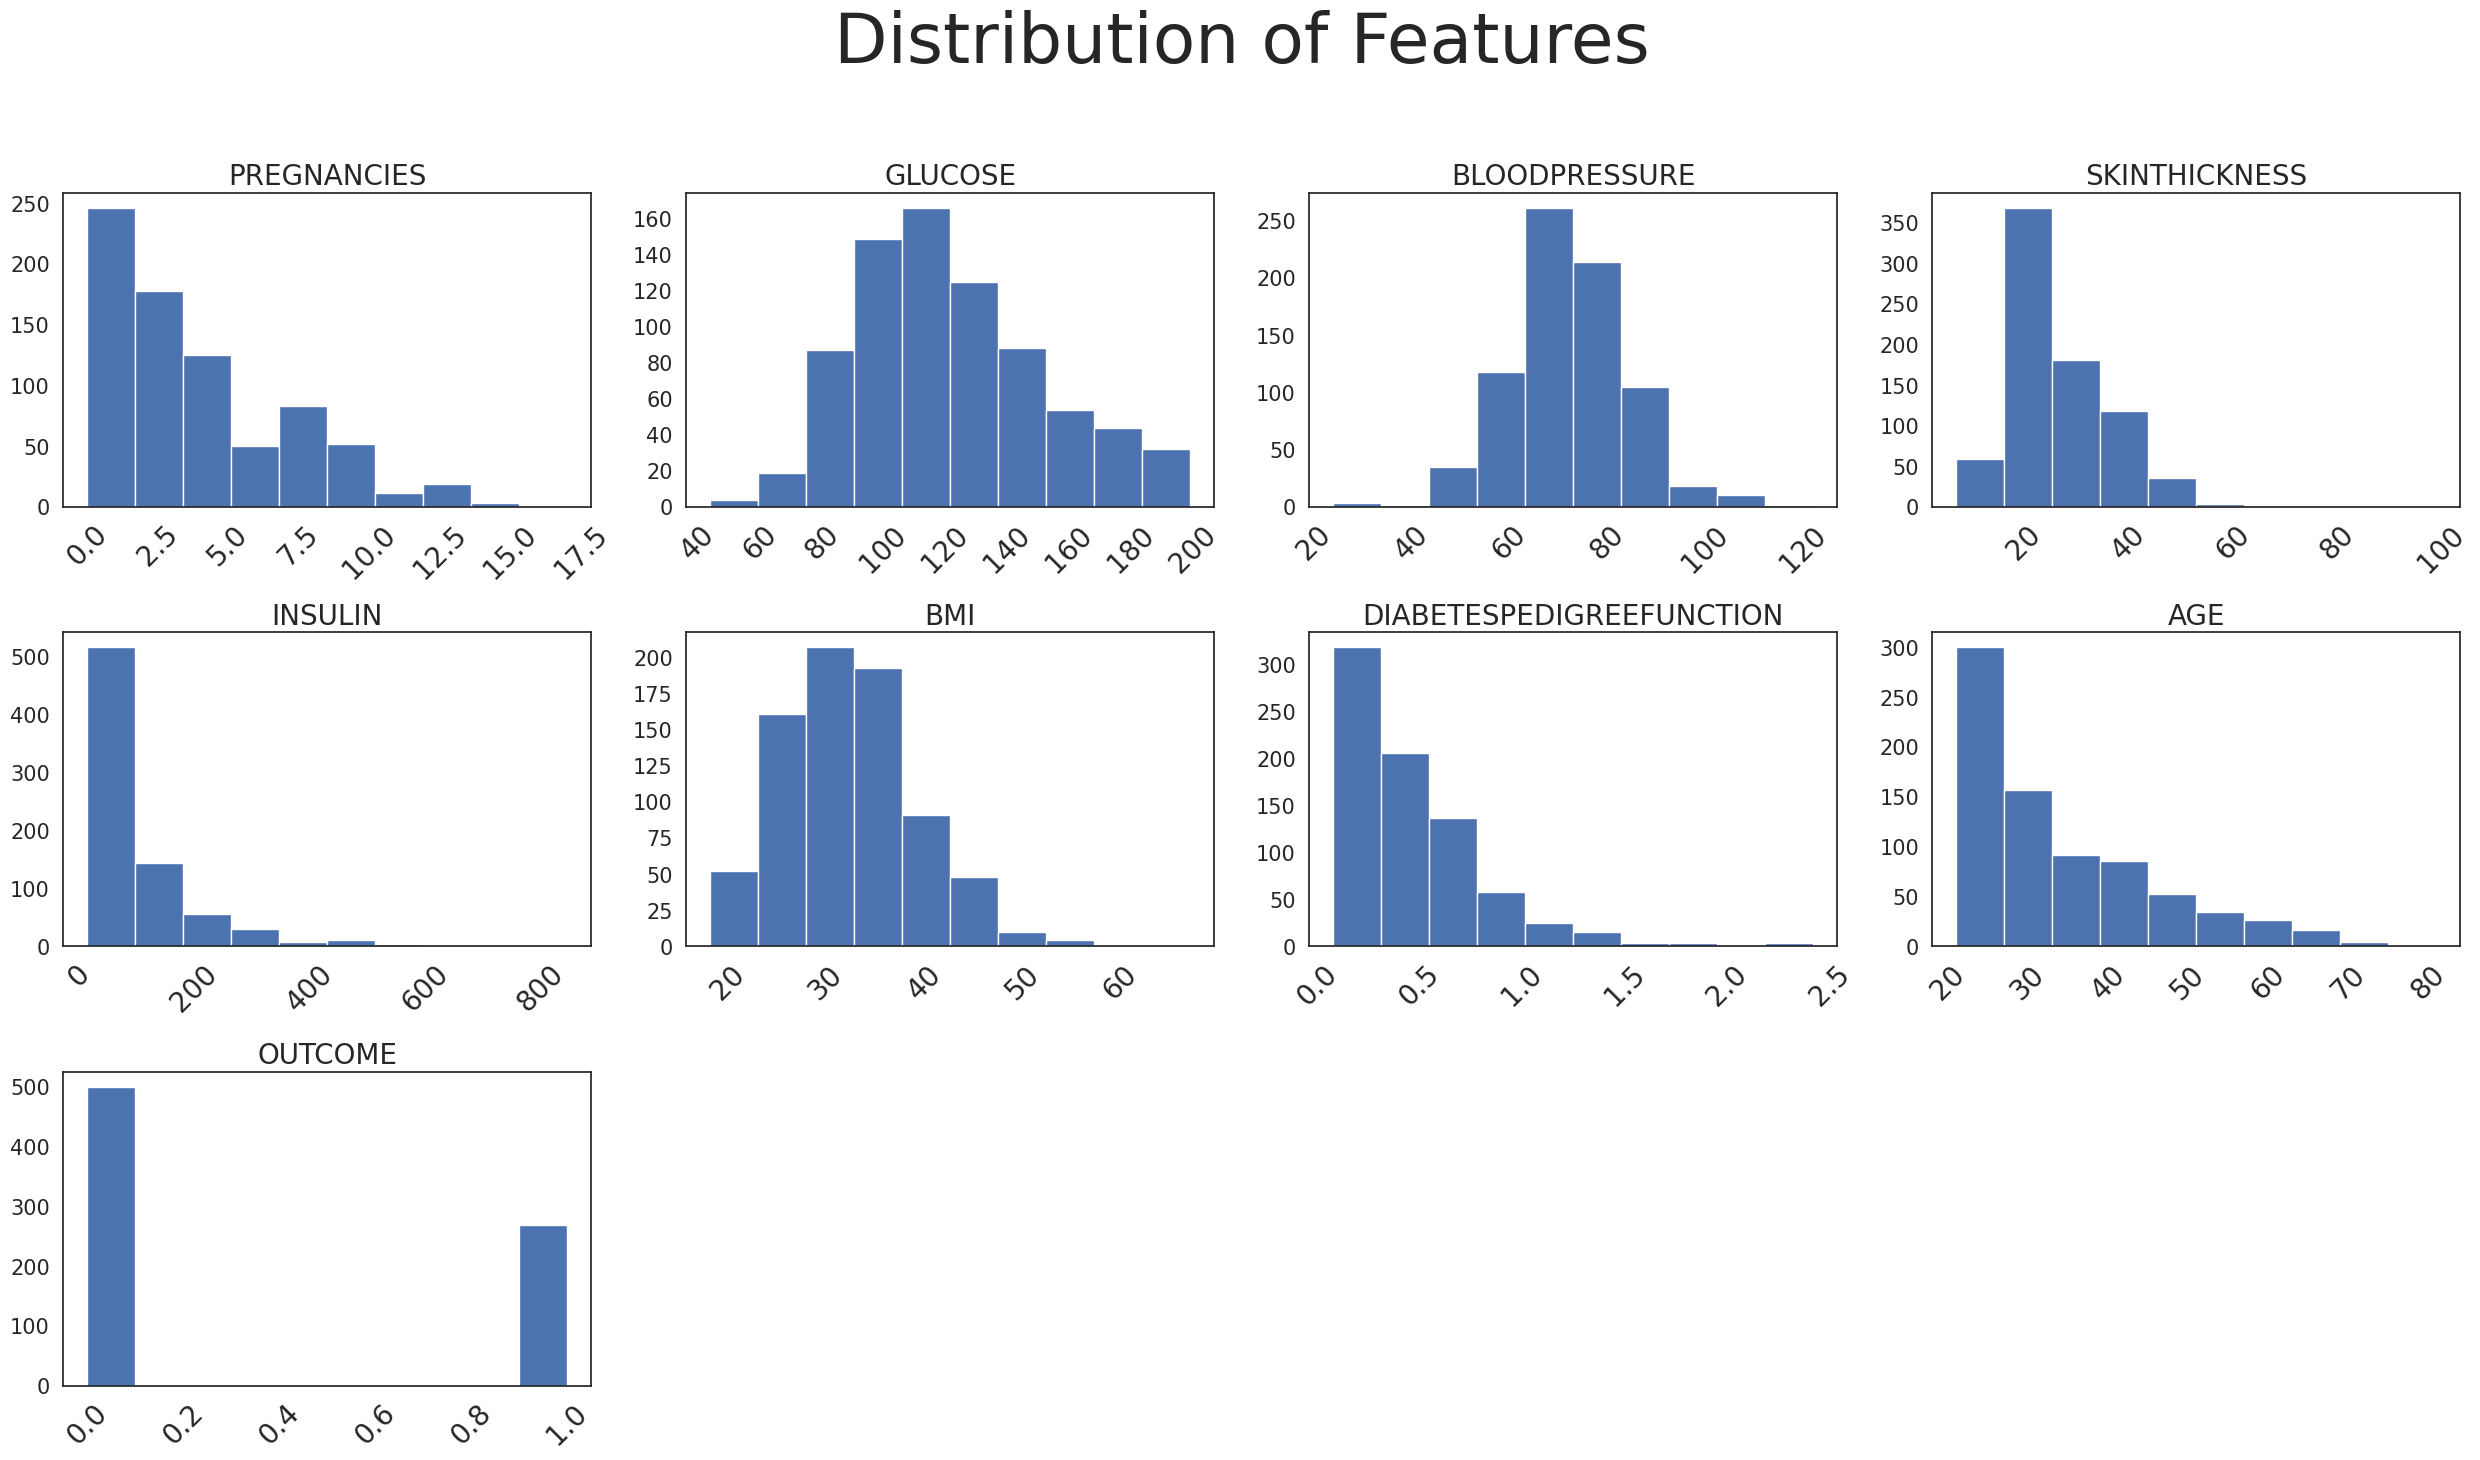

In [ ]:
fig = plt.figure(figsize=(25, 15))
st = fig.suptitle("Distribution of Features", fontsize=50, verticalalignment="center")
for col, num in zip(df.toPandas().describe().columns, range(1,11)):
  ax = fig.add_subplot(3,4, num)
  ax.hist(df.toPandas()[col])
  plt.grid(False)
  plt.xticks(rotation=45, fontsize=20)
  plt.yticks(fontsize=15)
  plt.title(col.upper(), fontsize=20)

plt.tight_layout()
st.set_y(0.95)
fig.subplots_adjust(top=0.85, hspace=0.4)
plt.show()

# Split Dataset & Build the model

#Logistic Regressor

Accuracy: 0.8383131030189853
+-----+----------+-----------------------------------------+
|label|prediction|probability                              |
+-----+----------+-----------------------------------------+
|0    |0.0       |[0.865276323108842,0.13472367689115805]  |
|0    |0.0       |[0.9442248752895503,0.05577512471044965] |
|0    |0.0       |[0.9126396608606047,0.08736033913939534] |
|0    |0.0       |[0.9733900479938228,0.026609952006177218]|
|0    |0.0       |[0.9645262795782472,0.035473720421752786]|
|0    |0.0       |[0.8851974510403842,0.11480254895961584] |
|0    |0.0       |[0.961237267348866,0.038762732651133947] |
|0    |0.0       |[0.9737097172806648,0.0262902827193352]  |
|0    |0.0       |[0.9046213359767016,0.09537866402329842] |
|0    |0.0       |[0.832480671637625,0.16751932836237504]  |
+-----+----------+-----------------------------------------+
only showing top 10 rows



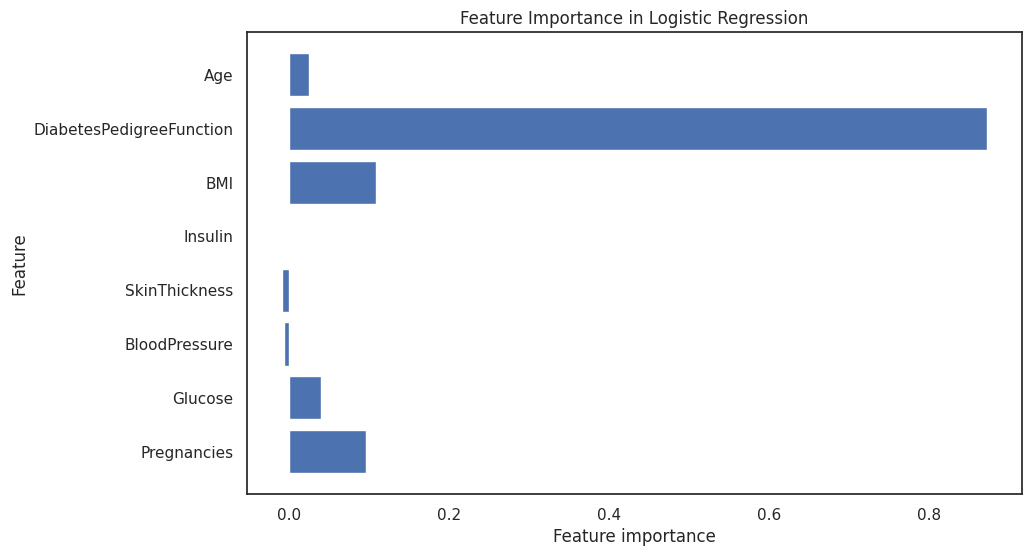

In [ ]:

# Import necessary libraries
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
feature_cols = df.columns[:-1]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
data = assembler.transform(df).select("features", "Outcome").withColumnRenamed("Outcome", "label")
train_data, test_data = data.randomSplit([0.8, 0.2], seed=1234)
lr = LogisticRegression(featuresCol="features", labelCol="label")
lr_model = lr.fit(train_data)
predictions = lr_model.transform(test_data)
# Evaluate the model using BinaryClassificationEvaluator
evaluator = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction", labelCol="label")
accuracy = evaluator.evaluate(predictions)
print("Accuracy:", accuracy)
predictions.select("label", "prediction", "probability").show(10, truncate=False)
feature_importance = lr_model.coefficients.toArray()
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance, tick_label=feature_cols)
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Logistic Regression')
plt.show()

#Decision Tree Classifier

Accuracy: 0.7212121212121212
+-----+----------+-----------------------------------------+
|label|prediction|probability                              |
+-----+----------+-----------------------------------------+
|0    |0.0       |[0.8235294117647058,0.17647058823529413] |
|0    |0.0       |[0.8848920863309353,0.11510791366906475] |
|0    |0.0       |[0.8848920863309353,0.11510791366906475] |
|0    |0.0       |[0.8848920863309353,0.11510791366906475] |
|0    |0.0       |[0.8848920863309353,0.11510791366906475] |
|0    |0.0       |[0.8848920863309353,0.11510791366906475] |
|0    |0.0       |[0.8848920863309353,0.11510791366906475] |
|0    |0.0       |[0.8848920863309353,0.11510791366906475] |
|0    |0.0       |[0.9705882352941176,0.029411764705882353]|
|0    |0.0       |[0.8848920863309353,0.11510791366906475] |
+-----+----------+-----------------------------------------+
only showing top 10 rows



<function matplotlib.pyplot.show(close=None, block=None)>

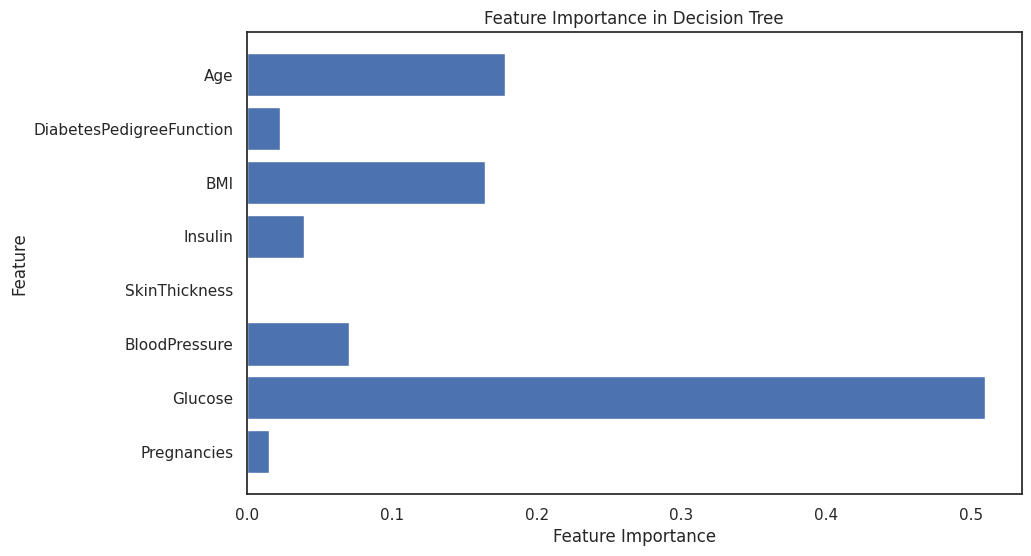

In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
feature_cols = df.columns[:-1] # All columns except the last one
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
data = assembler.transform(df).select("features", df.columns[-1]) # Use the last column as label
data = data.withColumnRenamed(df.columns[-1], "label")
train_data, test_data = data.randomSplit([0.8, 0.2], seed=1234)
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label")
dt_model = dt.fit(train_data)
predictions = dt_model.transform(test_data)
evaluator = MulticlassClassificationEvaluator(predictionCol="prediction", labelCol="label", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print("Accuracy:", accuracy)
predictions.select("label", "prediction","probability").show(10, truncate=False)
feature_importance = dt_model.featureImportances.toArray()

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance, tick_label=feature_cols)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Decision Tree')
plt.show

#Random Forest Classifier

Accuracy: 0.7636363636363637
+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0    |0.0       |[0.6655776555470347,0.33442234445296526]|
|0    |0.0       |[0.8599341436408887,0.14006585635911123]|
|0    |0.0       |[0.8640412598918292,0.13595874010817072]|
|0    |0.0       |[0.9558568109051258,0.04414318909487421]|
|0    |0.0       |[0.9558568109051258,0.04414318909487421]|
|0    |0.0       |[0.8270826735988864,0.17291732640111362]|
|0    |0.0       |[0.9558568109051258,0.04414318909487421]|
|0    |0.0       |[0.9457412039687096,0.05425879603129039]|
|0    |0.0       |[0.9240163539038504,0.07598364609614958]|
|0    |0.0       |[0.8445045313848639,0.15549546861513605]|
+-----+----------+----------------------------------------+
only showing top 10 rows



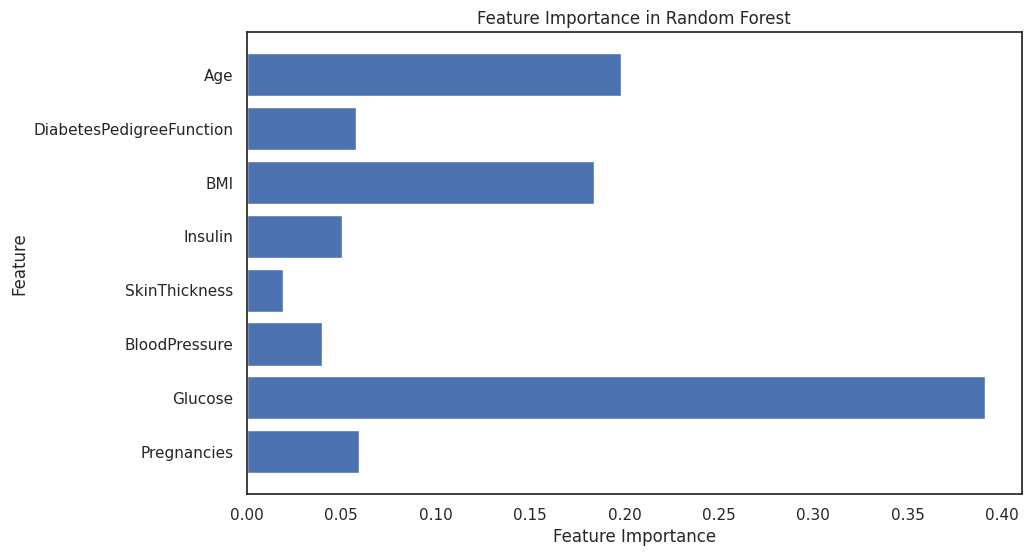

In [ ]:
from pyspark.ml.classification import RandomForestClassifier
feature_cols = df.columns[:-1]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
data = assembler.transform(df).select("features", df.columns[-1])
data = data.withColumnRenamed(df.columns[-1], "label")
train_data, test_data = data.randomSplit([0.8, 0.2], seed=1234)
rf = RandomForestClassifier(featuresCol="features", labelCol="label")
rf_model = rf.fit(train_data)
predictions = rf_model.transform(test_data)
evaluator = MulticlassClassificationEvaluator(predictionCol="prediction", labelCol="label", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print("Accuracy:", accuracy)
predictions.select("label", "prediction","probability").show(10, truncate=False)
feature_importance = rf_model.featureImportances.toArray()

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance, tick_label=feature_cols)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Random Forest')
plt.show()

#GBT Classifier

Accuracy: 0.7090909090909091
+-----+----------+-----------------------------------------+
|label|prediction|probability                              |
+-----+----------+-----------------------------------------+
|0    |0.0       |[0.9089324079642942,0.0910675920357058]  |
|0    |0.0       |[0.8158146723635245,0.18418532763647555] |
|0    |0.0       |[0.8542705253145401,0.14572947468545994] |
|0    |0.0       |[0.9467772337479035,0.05322276625209654] |
|0    |0.0       |[0.949039719567901,0.05096028043209899]  |
|0    |0.0       |[0.8727741245942319,0.12722587540576813] |
|0    |0.0       |[0.9739193976263583,0.026080602373641737]|
|0    |0.0       |[0.9289039628692694,0.07109603713073065] |
|0    |0.0       |[0.9332819629743633,0.06671803702563672] |
|0    |0.0       |[0.7266236386833984,0.2733763613166016]  |
+-----+----------+-----------------------------------------+
only showing top 10 rows



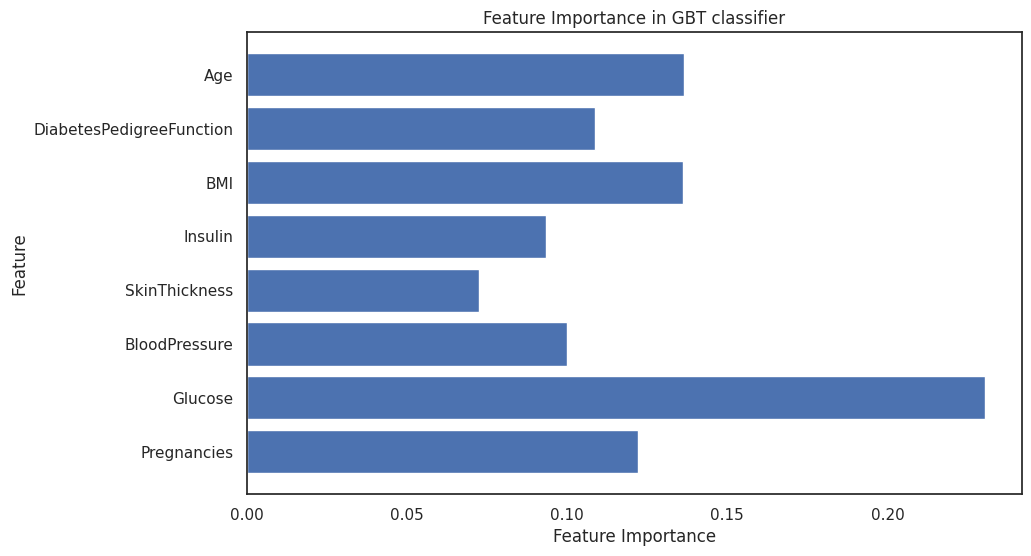

In [ ]:
from pyspark.ml.classification import GBTClassifier
feature_cols = df.columns[:-1] # All columns except the last one
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
data = assembler.transform(df).select("features", df.columns[-1]) # Use the last column as label
data = data.withColumnRenamed(df.columns[-1], "label")
train_data, test_data = data.randomSplit([0.8, 0.2], seed=1234)
gbt = GBTClassifier(featuresCol="features", labelCol="label")
gbt_model = gbt.fit(train_data)
predictions = gbt_model.transform(test_data)
evaluator = MulticlassClassificationEvaluator(predictionCol="prediction", labelCol="label", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print("Accuracy:", accuracy)
predictions.select("label", "prediction", "probability").show(10, truncate=False)
feature_importance = gbt_model.featureImportances.toArray()

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance, tick_label=feature_cols)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in GBT classifier')
plt.show()
